Author: Nicolas Legrand <nicolas.legrand@cas.au.dk>

In [1]:
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg
from pathlib import Path

plt.rcParams["figure.constrained_layout.use"] = True

In [2]:
cardiac_hgf_df = pd.read_csv(
    Path.cwd().parent.parent / "results" / "cardiac_hgf_summary.csv"
)
merged = pd.merge(
    cardiac_hgf_df[cardiac_hgf_df.session == 1],
    cardiac_hgf_df[cardiac_hgf_df.session == 2],
    on="participant_id",
    suffixes=("_del1", "_del2"),
)

/Users/au646069/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pingouin/correlation.py:134: UserWarning: The skipped correlation relies on the Minimum Covariance Determinant algorithm, which gives slightly different results in Python (scikit-learn) than in the original Matlab library (LIBRA). As such, the skipped correlation may be different from the Matlab robust correlation toolbox (see issue 164 on Pingouin's GitHub). Make sure to double check your results or use another robust correlation method.
  warnings.warn(
/Users/au646069/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/pingouin/correlation.py:134: UserWarning: The skipped correlation relies on the Minimum Covariance Determinant algorithm, which gives slightly different results in Python (scikit-learn) than in the original Matlab library (LIBRA). As such, the skipped correlation may be different from the Matlab robust correlation toolbox (see issue 164 on Pingouin's GitHub). Make sure to d

Cardiac beliefs
           n  outliers         r          CI95         p_val  power
skipped  187        10  0.542228  [0.43, 0.64]  6.452488e-15    1.0
Interoceptive sensitivity
           n  outliers         r          CI95     p_val     power
skipped  187        49  0.166536  [-0.0, 0.32]  0.050912  0.499755
Interoceptive precision
           n  outliers         r         CI95     p_val    power
skipped  187        22  0.268202  [0.12, 0.4]  0.000496  0.93929
Exteroceptive sensitivity
           n  outliers         r           CI95     p_val     power
skipped  187        20  0.114893  [-0.04, 0.26]  0.139275  0.316444


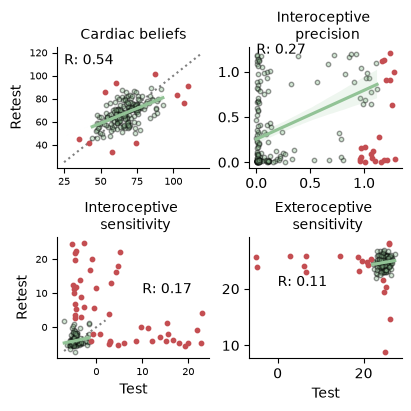

In [3]:
fig, axs = plt.subplots(figsize=(4, 4), nrows=2, ncols=2)

r, p, out = pg.correlation.skipped(
    x=merged["cardiac_belief_del1"].to_numpy(),
    y=merged["cardiac_belief_del2"].to_numpy(),
)
sns.regplot(
    x=merged["cardiac_belief_del1"][~out],
    y=merged["cardiac_belief_del2"][~out],
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolors": "k"},
    color="#92c396",
    ax=axs[0, 0],
)
axs[0, 0].annotate(
    f"R: {
        round(
            r,
            2,
        )
    }",
    (25, 110),
)
axs[0, 0].scatter(
    x=merged["cardiac_belief_del1"][out],
    y=merged["cardiac_belief_del2"][out],
    color="#c44e52",
    s=10,
)
print("Cardiac beliefs")
print(
    pg.corr(
        x=merged["cardiac_belief_del1"].to_numpy(),
        y=merged["cardiac_belief_del2"].to_numpy(),
        method="skipped",
    )
)

# ----------------------------------------------------------------------
r, p, out = pg.correlation.skipped(
    x=merged["logit_interoceptive_sensitivity_del1"].to_numpy(),
    y=merged["logit_interoceptive_sensitivity_del2"].to_numpy(),
)
sns.regplot(
    x=merged["logit_interoceptive_sensitivity_del1"][~out],
    y=merged["logit_interoceptive_sensitivity_del2"][~out],
    color="#92c396",
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolors": "k"},
    ax=axs[1, 0],
)
axs[1, 0].scatter(
    x=merged["logit_interoceptive_sensitivity_del1"][out],
    y=merged["logit_interoceptive_sensitivity_del2"][out],
    color="#c44e52",
    s=10,
)
axs[1, 0].annotate(
    f"R: {
        round(
            r,
            2,
        )
    }",
    (10, 10),
)
print("Interoceptive sensitivity")
print(
    pg.corr(
        x=merged["logit_interoceptive_sensitivity_del1"].to_numpy(),
        y=merged["logit_interoceptive_sensitivity_del2"].to_numpy(),
        method="skipped",
    )
)

# ----------------------------------------------------------------------
r, p, out = pg.correlation.skipped(
    x=merged["interoceptive_precision_del1"].to_numpy(),
    y=merged["interoceptive_precision_del2"].to_numpy(),
)
sns.regplot(
    x=merged["interoceptive_precision_del1"][~out],
    y=merged["interoceptive_precision_del2"][~out],
    color="#92c396",
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolors": "k"},
    ax=axs[0, 1],
)
axs[0, 1].scatter(
    x=merged["interoceptive_precision_del1"][out],
    y=merged["interoceptive_precision_del2"][out],
    color="#c44e52",
    s=10,
)
axs[0, 1].annotate(
    f"R: {
        round(
            r,
            2,
        )
    }",
    (0, 1.2),
)
print("Interoceptive precision")
print(
    pg.corr(
        x=merged["interoceptive_precision_del1"].to_numpy(),
        y=merged["interoceptive_precision_del2"].to_numpy(),
        method="skipped",
    )
)

# ----------------------------------------------------------------------
r, p, out = pg.correlation.skipped(
    x=merged["logit_exteroceptive_sensitivity_del1"].to_numpy(),
    y=merged["logit_exteroceptive_sensitivity_del2"].to_numpy(),
)
sns.regplot(
    x=merged["logit_exteroceptive_sensitivity_del1"][~out],
    y=merged["logit_exteroceptive_sensitivity_del2"][~out],
    color="#92c396",
    scatter_kws={"s": 10, "alpha": 0.4, "edgecolors": "k"},
    ax=axs[1, 1],
)
axs[1, 1].scatter(
    x=merged["logit_exteroceptive_sensitivity_del1"][out],
    y=merged["logit_exteroceptive_sensitivity_del2"][out],
    color="#c44e52",
    s=10,
)
axs[1, 1].annotate(
    f"R: {
        round(
            r,
            2,
        )
    }",
    (0, 20.5),
)
print("Exteroceptive sensitivity")
print(
    pg.corr(
        x=merged["logit_exteroceptive_sensitivity_del1"].to_numpy(),
        y=merged["logit_exteroceptive_sensitivity_del2"].to_numpy(),
        method="skipped",
    )
)

axs[0, 0].plot((25, 120), (25, 120), linestyle=":", color="gray", zorder=0)
axs[0, 0].tick_params(axis="both", labelsize=7)
axs[1, 0].plot((-7, 2), (-7, 2), linestyle=":", color="gray", zorder=0)
axs[1, 0].tick_params(axis="both", labelsize=7)

axs[0, 0].set_title("Cardiac beliefs", fontsize=10)
axs[0, 1].set_title("Interoceptive \n precision", fontsize=10)
axs[1, 0].set_title("Interoceptive \n sensitivity", fontsize=10)
axs[1, 1].set_title("Exteroceptive \n sensitivity", fontsize=10)

axs[0, 0].set(xlabel=None, ylabel="Retest")
axs[1, 0].set(xlabel="Test", ylabel="Retest")
axs[0, 1].set(xlabel=None, ylabel=None)
axs[1, 1].set(xlabel="Test", ylabel=None)

sns.despine()

plt.savefig(Path().cwd().parent.parent / "figures" / "figure_4_reliability.svg")